In [33]:
import torch, torchvision
from torch import nn
from torch import optim
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import copy
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

In [35]:
numb_batch = 64

In [37]:
T = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])
train_data = torchvision.datasets.MNIST('mnist_data', train=True, download=True, transform=T)
val_data = torchvision.datasets.MNIST('mnist_data', train=False, download=True, transform=T)

train_dl = torch.utils.data.DataLoader(train_data, batch_size = numb_batch)
val_dl = torch.utils.data.DataLoader(val_data, batch_size = numb_batch)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 573kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.58MB/s]


In [39]:
def create_lenet():
    model = nn.Sequential(
        nn.Conv2d(1, 6, 5, padding=2),
        nn.ReLU(),
        nn.AvgPool2d(2, stride=2),
        nn.Conv2d(6, 16, 5, padding=0),
        nn.ReLU(),
        nn.AvgPool2d(2, stride=2),
        nn.Flatten(),
        nn.Linear(400, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
    )
    return model

In [41]:
def validate(model, data):
    correct = 0
    for i, (images, labels) in enumerate(data):
        images = images.to("cpu")
        x = model(images)
        value, pred = torch.max(x, 1)
        correct += (pred == labels).sum().item()
    accuracy = 100 * correct / len(data.dataset)
    return accuracy

In [43]:
def train(numb_epoch=3, lr=1e-3, device="cpu"):
    accuracies = []
    cnn = create_lenet().to(device)
    cec = nn.CrossEntropyLoss()
    optimizer = optim.Adam(cnn.parameters(), lr=lr)
    max_accuracy = 0
    for epoch in range(numb_epoch):
        for i, (images, labels) in enumerate(train_dl):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            pred = cnn(images)
            loss = cec(pred, labels)
            loss.backward()
            optimizer.step()
        accuracy = float(validate(cnn, val_dl))
        accuracies.append(accuracy)
        if accuracy > max_accuracy:
            best_model = copy.deepcopy(cnn)
            max_accuracy = accuracy
            print("Saving Best Model with Accuracy: ", accuracy)
        print('Epoch:', epoch+1, "Accuracy :", accuracy, '%')
    plt.plot(accuracies)
    return best_model

In [45]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
    print("No Cuda Available")
device

No Cuda Available


device(type='cpu')

Saving Best Model with Accuracy:  95.23
Epoch: 1 Accuracy : 95.23 %
Saving Best Model with Accuracy:  97.37
Epoch: 2 Accuracy : 97.37 %
Saving Best Model with Accuracy:  97.96
Epoch: 3 Accuracy : 97.96 %
Saving Best Model with Accuracy:  98.39
Epoch: 4 Accuracy : 98.39 %
Saving Best Model with Accuracy:  98.65
Epoch: 5 Accuracy : 98.65 %
Saving Best Model with Accuracy:  98.77
Epoch: 6 Accuracy : 98.77 %
Epoch: 7 Accuracy : 98.57 %
Epoch: 8 Accuracy : 98.33 %
Epoch: 9 Accuracy : 98.72 %
Epoch: 10 Accuracy : 98.72 %
Epoch: 11 Accuracy : 98.62 %
Epoch: 12 Accuracy : 98.74 %
Saving Best Model with Accuracy:  98.87
Epoch: 13 Accuracy : 98.87 %
Epoch: 14 Accuracy : 98.69 %
Epoch: 15 Accuracy : 98.87 %
Saving Best Model with Accuracy:  98.99
Epoch: 16 Accuracy : 98.99 %
Epoch: 17 Accuracy : 98.83 %
Epoch: 18 Accuracy : 98.9 %
Epoch: 19 Accuracy : 98.78 %
Epoch: 20 Accuracy : 98.95 %
Epoch: 21 Accuracy : 98.87 %
Epoch: 22 Accuracy : 98.67 %
Epoch: 23 Accuracy : 98.77 %
Epoch: 24 Accuracy : 98

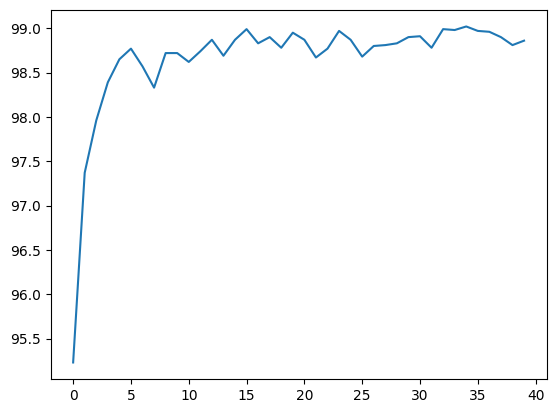

In [47]:
lenet = train(40, device=device)

In [49]:
torch.save(lenet.state_dict(), "lenet.pth")

In [51]:
lenet = create_lenet().to(device)
lenet.load_state_dict(torch.load("lenet.pth"))
lenet.eval()

Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): ReLU()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)

In [53]:
def predict_dl(model, data):
    y_pred = []
    y_true = []
    for i, (images, labels) in enumerate(data):
        images = images.cuda()
        x = model(images)
        value, pred = torch.max(x, 1)
        pred = pred.data.cpu()
        y_pred.extend(list(pred.numpy()))
        y_true.extend(list(labels.numpy()))
    return np.array(y_pred), np.array(y_true)

In [55]:
def inference(path, model, device):
    r = requests.get(path)
    with BytesIO(r.content) as f:
        img = Image.open(f).convert(mode="L")
        img = img.resize((28, 28))
        x = (255 - np.expand_dims(np.array(img), -1))/255.
    with torch.no_grad():
        pred = model(torch.unsqueeze(T(x), axis=0).float().to(device))
        return F.softmax(pred, dim=-1).cpu().numpy()

In [57]:
path = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS9e2HFHKDzi1sqRxvYWqaOH2BUxd7fWfC4nVmEhlQ7Jg6eOXnNyig1S0bY5EYajVnZyZg&usqp=CAU"
r = requests.get(path)
with BytesIO(r.content) as f:
    img = Image.open(f).convert(mode="L")
    img = img.resize((28, 28))
x = (255 - np.expand_dims(np.array(img), -1))/255.

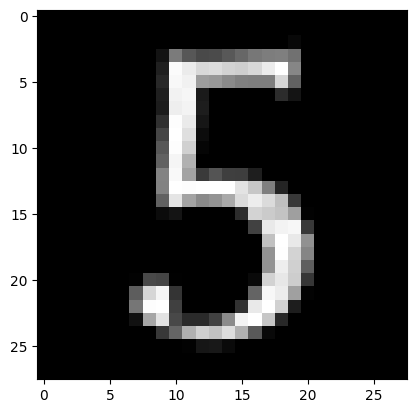

In [59]:
plt.imshow(x.squeeze(-1), cmap="gray")

In [61]:
pred = inference(path, lenet, device=device)
pred_idx = np.argmax(pred)
print(f"Predicted: {pred_idx}, Prob: {pred[0][pred_idx]*100} %")

Predicted: 5, Prob: 100.0 %


In [63]:
pred

array([[7.2855951e-26, 1.6773120e-23, 1.9698936e-28, 3.3256681e-17,
        6.6138891e-22, 1.0000000e+00, 3.9850161e-23, 9.1477718e-19,
        3.5316485e-22, 2.6529350e-14]], dtype=float32)